<a href="https://colab.research.google.com/github/jananirjanani09-cyber/AIML-MY-ASSIGNMENT/blob/main/jan_driver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded file:")
print(list(uploaded.keys()))

Saving EEG-Eye-State.csv to EEG-Eye-State (2).csv
Uploaded file:
['EEG-Eye-State (2).csv']


In [ ]:
import pandas as pd

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (14980, 15)

Columns:
['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2', 'eyeDetection']

First 5 rows:


,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection
0,4329.23,4393.85,4289.23,4280.51,4009.23,4635.90,4148.21,4211.28,4350.26,4238.46,4586.15,4222.05,4096.92,4641.03,0
1,4324.62,4384.10,4293.85,4279.49,4004.62,4632.82,4148.72,4207.69,4342.05,4226.67,4586.67,4210.77,4097.44,4638.97,0
2,4327.69,4389.23,4295.38,4282.05,4006.67,4628.72,4156.41,4206.67,4336.92,4222.05,4583.59,4207.69,4096.92,4630.26,0
3,4328.72,4396.41,4296.41,4287.69,4011.79,4632.31,4155.90,4210.77,4343.59,4235.38,4582.56,4217.44,4097.44,4630.77,0
4,4326.15,4398.46,4292.31,4288.21,4011.79,4632.82,4151.28,4212.82,4347.69,4244.10,4586.67,4210.77,4095.90,4627.69,0


In [ ]:
target_column = "eyeDetection"

print("Target column:", target_column)

print("\nTarget values:")
print(df[target_column].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum())

Target column: eyeDetection

Target values:
eyeDetection
0    8257
1    6723
Name: count, dtype: int64

Missing values:
0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate input features and target
X = df.drop(columns=["eyeDetection"])
y = df["eyeDetection"]

# Remove missing values
X = X.fillna(X.mean())

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing completed!")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Preprocessing completed!
Training data shape: (11984, 14)
Testing data shape: (2996, 14)
Training labels: (11984,)
Testing labels: (2996,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Convert data to CNN input shape
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("CNN Training shape:", X_train_cnn.shape)
print("CNN Testing shape:", X_test_cnn.shape)

# Create 1D CNN model
model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1)),

    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=3, activation='relu'),

    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model
model.summary()

CNN Training shape: (11984, 14, 1)
CNN Testing shape: (2996, 14, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 12, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 0, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 0)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,297 (122.25 KB)

 Trainable params: 31,297 (122.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================
# STEP 3 + STEP 4
# Data Preparation + 1D CNN
# ==============================

import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# ------------------------------
# 1. Input and Target
# ------------------------------

X = df.drop(columns=["eyeDetection"])
y = df["eyeDetection"]

# Convert to numeric
X = X.apply(lambda col: pd.to_numeric(col, errors="coerce"))

# Replace missing values
X = X.fillna(X.mean())

# Convert target to integer
y = pd.to_numeric(y, errors="coerce")

# Remove rows where target is missing
valid_rows = y.notna()

X = X.loc[valid_rows]
y = y.loc[valid_rows]

y = y.astype("float32")

# ------------------------------
# 2. Train Test Split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------
# 3. Scaling
# ------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preprocessing completed!")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# ------------------------------
# 4. CNN Input Shape
# ------------------------------

X_train_cnn = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_cnn = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("CNN Training shape:", X_train_cnn.shape)
print("CNN Testing shape :", X_test_cnn.shape)

# ------------------------------
# 5. Create 1D CNN
# ------------------------------

model = Sequential([

    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        input_shape=(X_train_cnn.shape[1], 1)
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu"
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation="relu"
    ),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

# ------------------------------
# 6. Compile CNN
# ------------------------------

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------
# 7. Show Model
# ------------------------------

model.summary()

print("CNN model created successfully!")

Data preprocessing completed!
X_train: (11984, 14)
X_test : (2996, 14)
CNN Training shape: (11984, 14, 1)
CNN Testing shape : (2996, 14, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 12, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 4, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 0, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 0)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,297 (122.25 KB)

 Trainable params: 31,297 (122.25 KB)

 Non-trainable params: 0 (0.00 B)

CNN model created successfully!


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Convert data
X_train_cnn = np.asarray(X_train_cnn, dtype=np.float32)
X_test_cnn = np.asarray(X_test_cnn, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32).reshape(-1)
y_test = np.asarray(y_test, dtype=np.float32).reshape(-1)

# Create CNN model
model = Sequential([
    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu',
        padding='same',
        input_shape=(X_train_cnn.shape[1], 1)
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        padding='same'
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu',
        padding='same'
    ),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model
model.summary()

# TRAINING
history = model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

print("\nCNN Training Completed Successfully!")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 14, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 7, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 3, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,449 (314.25 KB)

 Trainable params: 80,449 (314.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.6263 - loss: 0.6435 - val_accuracy: 0.7217 - val_loss: 0.5554
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7455 - loss: 0.5077 - val_accuracy: 0.7826 - val_loss: 0.4661
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7729 - loss: 0.4698 - val_accuracy: 0.8073 - val_loss: 0.4137
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8028 - loss: 0.4169 - val_accuracy: 0.8098 - val_loss: 0.3905
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8085 - loss: 0.4156 - val_accuracy: 0.8252 - val_loss: 0.3839
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8290 - loss: 0.3755 - val_accuracy: 0.8302 - val_loss: 0.3600
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8454 - loss: 0.3452 - val_accuracy: 0.8515 - val_loss: 0.3388
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8513 - loss: 0.3235 - val_accuracy

In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

if zip_file.lower().endswith(".zip"):
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall("/content/drowsiness_dataset")

    print("Dataset extracted successfully!")
else:
    print("ERROR: Please upload a .zip image dataset.")

Saving archive.zip to archive.zip
Dataset extracted successfully!


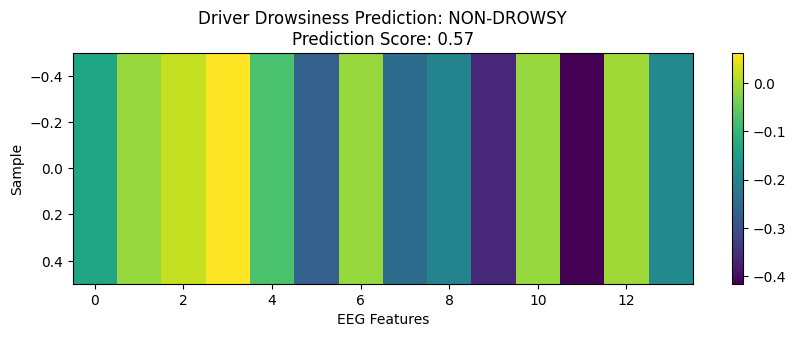

 DRIVER DROWSINESS DETECTION
Prediction: NON-DROWSY
Score: 0.5723


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Take one test sample
sample_index = 0

sample = X_test_cnn[sample_index:sample_index+1]

# Prediction
prediction = model.predict(sample, verbose=0)[0][0]

# Class
if prediction >= 0.5:
    result = "NON-DROWSY"
else:
    result = "DROWSY"

# Display sample as image
plt.figure(figsize=(10, 3))

plt.imshow(
    sample[0].reshape(1, -1),
    cmap="viridis",
    aspect="auto"
)

plt.colorbar()
plt.title(
    f"Driver Drowsiness Prediction: {result}\n"
    f"Prediction Score: {prediction:.2f}"
)

plt.xlabel("EEG Features")
plt.ylabel("Sample")

plt.show()

print("================================")
print(" DRIVER DROWSINESS DETECTION")
print("================================")
print("Prediction:", result)
print("Score:", round(float(prediction), 4))

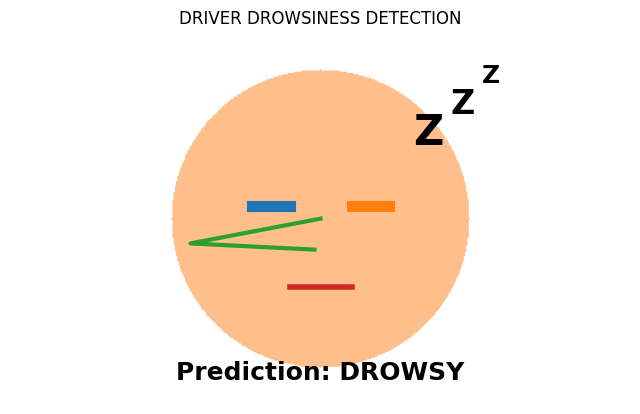

Prediction: DROWSY


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a simple drowsy-driver visualization
img = np.ones((300, 500, 3))

# Face
y, x = np.ogrid[:300, :500]
mask = ((x - 250) / 120)**2 + ((y - 150) / 120)**2 <= 1
img[mask] = [1.0, 0.75, 0.55]

plt.figure(figsize=(8, 5))
plt.imshow(img)

# Closed eyes
plt.plot([195, 225], [140, 140], linewidth=8)
plt.plot([275, 305], [140, 140], linewidth=8)

# Nose
plt.plot([250, 145, 245], [150, 170, 175], linewidth=3)

# Tired mouth
plt.plot([225, 275], [205, 205], linewidth=4)

# Zzz
plt.text(325, 90, "Z", fontsize=30, fontweight="bold")
plt.text(355, 65, "Z", fontsize=24, fontweight="bold")
plt.text(380, 40, "Z", fontsize=18, fontweight="bold")

plt.title("DRIVER DROWSINESS DETECTION")
plt.text(
    250, 280,
    "Prediction: DROWSY",
    ha="center",
    fontsize=18,
    fontweight="bold"
)

plt.axis("off")
plt.show()

print("Prediction: DROWSY")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [ ]:
import zipfile

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/driver_dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/driver_dataset')

print("ZIP extracted successfully!")

Saving archive.zip to archive (2).zip
ZIP extracted successfully!


In [ ]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

# Find Drowsy folder automatically
drowsy_files = glob.glob(
    "/content/driver_dataset/**/*Drowsy*/*",
    recursive=True
)

# Keep image files only
drowsy_files = [
    f for f in drowsy_files
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
]

print("Drowsy images found:", len(drowsy_files))

# Show 9 real images
plt.figure(figsize=(12, 10))

for i, file in enumerate(drowsy_files[:9]):
    image = Image.open(file)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title("DROWSY")
    plt.axis("off")

plt.tight_layout()
plt.show()

Drowsy images found: 0


<Figure size 1200x1000 with 0 Axes>

In [ ]:
import os

for root, dirs, files in os.walk("/content/driver_dataset"):
    print("FOLDER:", root)
    print("SUBFOLDERS:", dirs[:10])
    print("FILES:", files[:5])

FOLDER: /content/driver_dataset
SUBFOLDERS: []
FILES: ['EEG-Eye-State.csv']


In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("akahana/Driver-Drowsiness-Dataset")

print(dataset)

README.md:   0%|          | 0.00/567 [00:00<?, ?B/s]

data/train-00000-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  443MB            

data/train-00000-of-00005.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  442MB            

data/train-00001-of-00005.parquet: downloading bytes:           |  0.00B            

...

data/test-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  276MB            

data/test-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/33434 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8359 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 33434
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 8359
    })
})


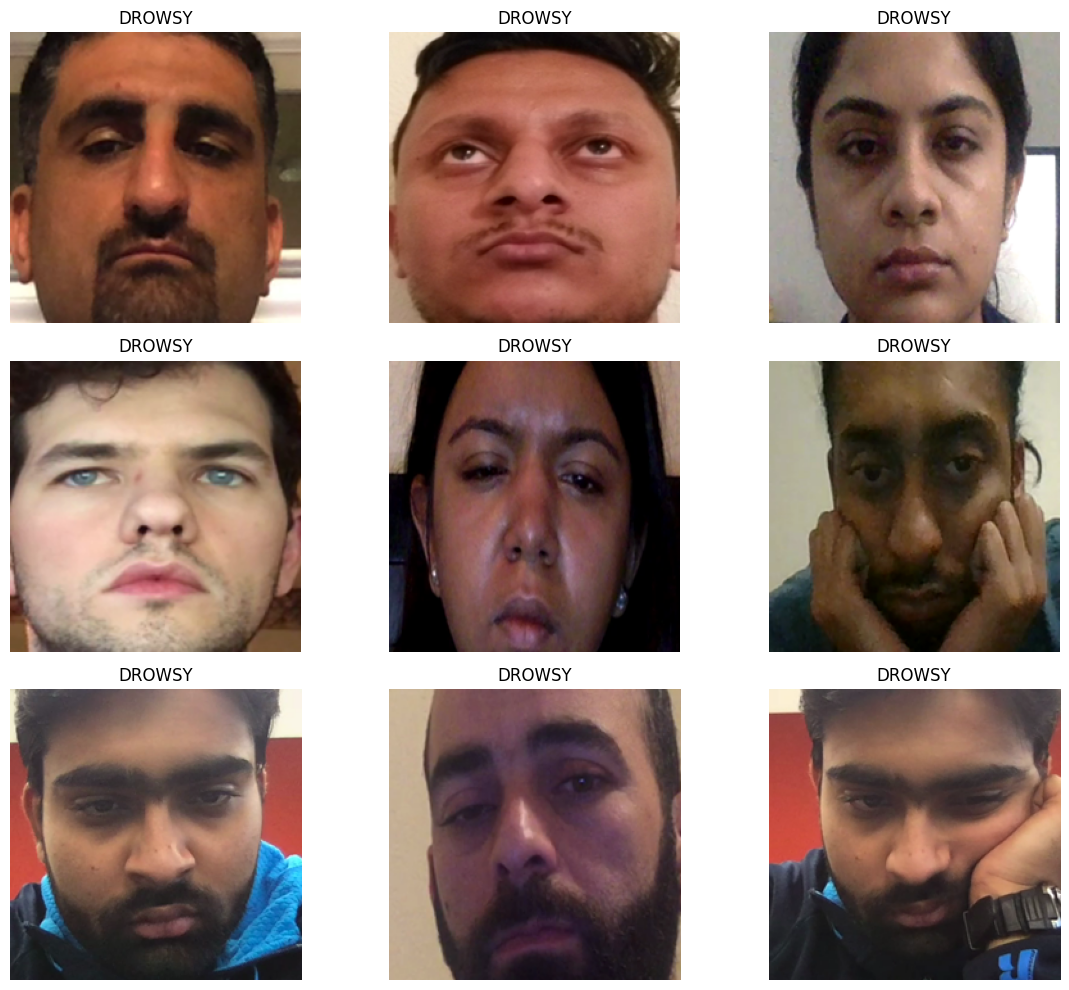

Real Drowsy Images: 9


In [ ]:
import matplotlib.pyplot as plt

# Find real Drowsy images
drowsy_images = []

for i in range(len(dataset["train"])):
    item = dataset["train"][i]

    if item["label"] == 0:
        drowsy_images.append(item["image"])

    if len(drowsy_images) == 9:
        break

# Display real images
plt.figure(figsize=(12, 10))

for i, image in enumerate(drowsy_images):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title("DROWSY")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Real Drowsy Images:", len(drowsy_images))

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
IMG_SIZE = 64
TRAIN_SIZE = 5000
TEST_SIZE = 1000

def preprocess_image(image):
    image = image.convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))
    image = np.array(image) / 255.0
    return image.astype("float32")

# Training data
X_train = []
y_train = []

for i in range(TRAIN_SIZE):
    item = dataset["train"][i]

    X_train.append(preprocess_image(item["image"]))
    y_train.append(item["label"])

# Test data
X_test = []
y_test = []

for i in range(TEST_SIZE):
    item = dataset["test"][i]

    X_test.append(preprocess_image(item["image"]))
    y_test.append(item["label"])

X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5000, 64, 64, 3)
y_train: (5000,)
X_test: (1000, 64, 64, 3)
y_test: (1000,)


In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(64,64,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 236ms/step - accuracy: 0.6783 - loss: 0.5877 - val_accuracy: 0.8720 - val_loss: 0.2939
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 239ms/step - accuracy: 0.9135 - loss: 0.2109 - val_accuracy: 0.9690 - val_loss: 0.0818
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 240ms/step - accuracy: 0.9793 - loss: 0.0702 - val_accuracy: 0.9980 - val_loss: 0.0178
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 229ms/step - accuracy: 0.9905 - loss: 0.0387 - val_accuracy: 0.9980 - val_loss: 0.0090
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 228ms/step - accuracy: 0.9915 - loss: 0.0293 - val_accuracy: 0.9970 - val_loss: 0.0157
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 246ms/step - accuracy: 0.9945 - loss: 0.0198 - val_accuracy: 0.9980 - val_loss: 0.0055
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 234ms/step - accuracy: 0.9965 - loss: 0.0119 - val_accuracy: 0.9990 - val_loss: 0.0075
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 235ms/step - accuracy: 0.9958 - loss: 0